In [1]:
# import important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Information about dataset attributes -

Pregnancies: To express the Number of pregnancies

Glucose: To express the Glucose level in blood

BloodPressure: To express the Blood pressure measurement

SkinThickness: To express the thickness of the skin

Insulin: To express the Insulin level in blood

BMI: To express the Body mass index

DiabetesPedigreeFunction: To express the Diabetes percentage

Age: To express the age

Outcome: To express the final result 1 is Yes and 0 is No

# Step 2 -- Get Insight of data
## Basic EDA and Stastical analysis

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
# to check all the statistical values of dataset
df.describe().T # to detect the anomalies in data

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Few Questions arises :

min value in some columns is zero. Is it valid?

Zero as min value found in following columns :

Glucose,Blood Prseeure,skinthickness,Insulin,BMI

In [11]:
# We create a copy of data to deal with minimum value zero in some columns
df_copy = df.copy()

In [12]:
# Make list of columns those having min value zero
lst_zero_min=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

In [13]:
lst_zero_min

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [15]:
df_copy[lst_zero_min] = df_copy[lst_zero_min].replace(0, np.nan)

In [16]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [17]:
df_copy['Glucose'].mean()

np.float64(121.6867627785059)

In [19]:
df_copy.fillna({'Glucose':122}, inplace = True)

In [21]:
df_copy.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [22]:
# Handle the null values by filling mean 
# SimpleImputer is sklearn class used to handle null values
from sklearn.impute import SimpleImputer
im = SimpleImputer(strategy='mean')


In [25]:
imdf = im.fit_transform(df_copy)
imdf

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]],
      shape=(768, 9))

In [26]:
type(imdf)

numpy.ndarray

In [27]:
imdf = pd.DataFrame(imdf)
imdf.head()

,0,1,2,3,4,5,6,7,8
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0,1.0


In [28]:
imdf.columns = df.columns

In [29]:
imdf

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.00000,180.000000,32.9,0.171,63.0,0.0
764,2.0,122.0,70.0,27.00000,155.548223,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.00000,112.000000,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,29.15342,155.548223,30.1,0.349,47.0,1.0


In [30]:
# Again check the nan values
imdf.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [32]:
# again we check the stastical values of dataset
imdf.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.000000,17.00
Glucose,768.0,121.688802,30.435959,44.000,99.75000,117.000000,140.250000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.000000,122.00
SkinThickness,768.0,29.153420,8.790942,7.000,25.00000,29.153420,32.000000,99.00
Insulin,768.0,155.548223,85.021108,14.000,121.50000,155.548223,155.548223,846.00
BMI,768.0,32.457464,6.875151,18.200,27.50000,32.400000,36.600000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.626250,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.000000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.000000,1.000000,1.00


<Axes: ylabel='Age'>

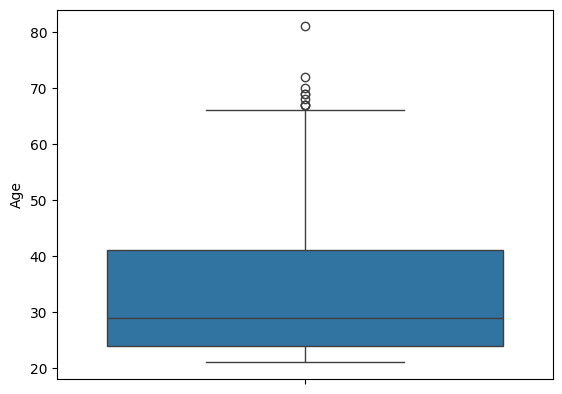

In [33]:
sns.boxplot(df['Age'])

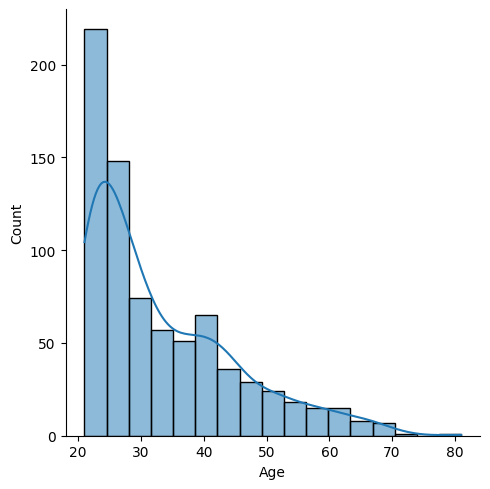

In [34]:
sns.displot(df['Age'], kde = True)

<Axes: >

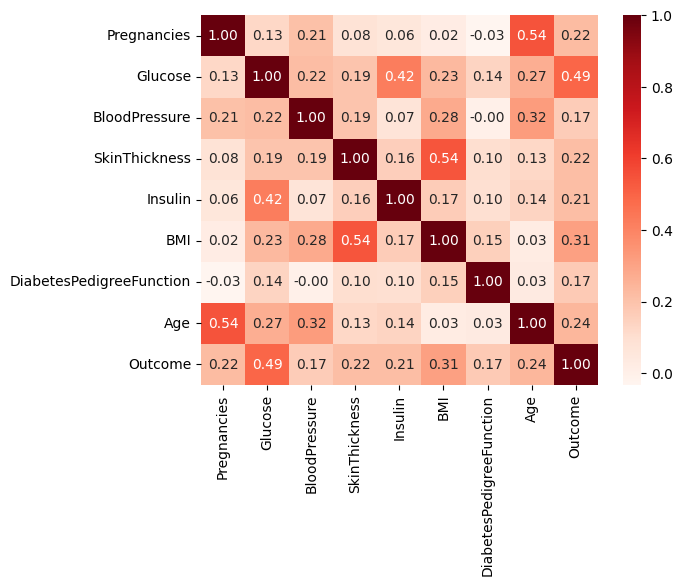

In [35]:
# We will check the correlation between all features and target feature
sns.heatmap(imdf.corr(), annot = True, cmap = 'Reds', fmt = '.2f')

<Axes: >

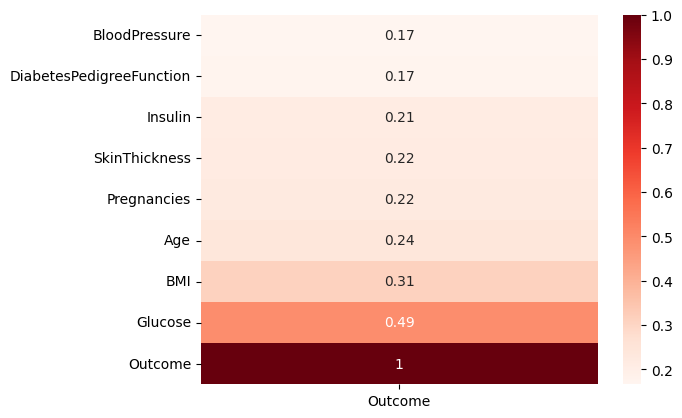

In [37]:
sns.heatmap(imdf.corr()[['Outcome']].sort_values(by = 'Outcome', ascending = True),
            annot = True, 
            cmap = 'Reds') # Sort in descending order

In [38]:
# Check data is balanced or not 
imdf['Outcome'].value_counts()

Outcome
0.0    500
1.0    268
Name: count, dtype: int64

<Axes: xlabel='Glucose', ylabel='BMI'>

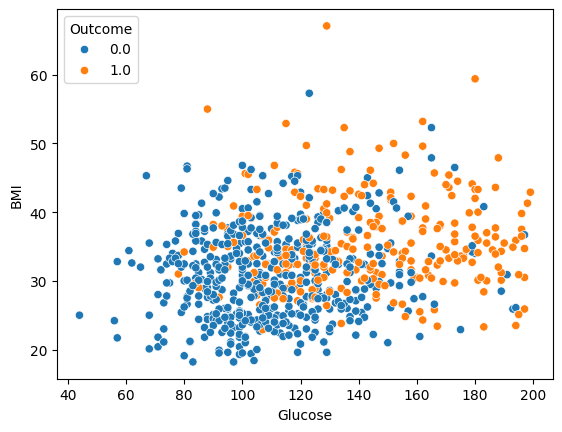

In [41]:
sns.scatterplot(x = imdf['Glucose'], y = imdf['BMI'], hue = imdf['Outcome'])

<Axes: xlabel='Age', ylabel='Glucose'>

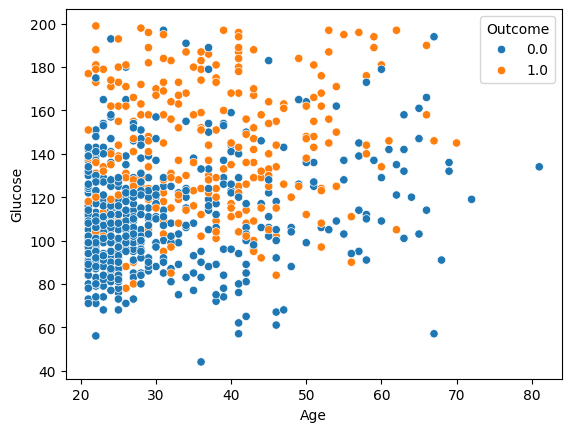

In [39]:
sns.scatterplot(x = imdf['Age'], y = imdf['Glucose'], hue = imdf['Outcome'])

<Axes: xlabel='Age', ylabel='BMI'>

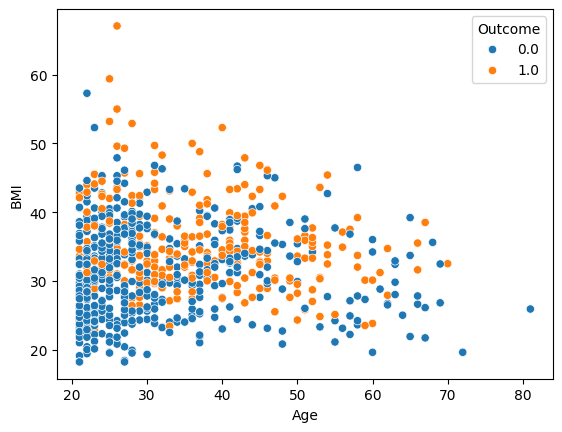

In [40]:
sns.scatterplot(x = imdf['Age'], y = imdf['BMI'], hue = imdf['Outcome'])

<Axes: xlabel='BloodPressure', ylabel='BMI'>

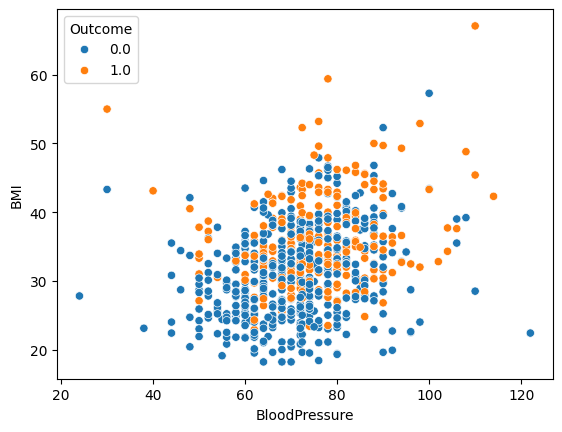

In [41]:
sns.scatterplot(x = imdf['BloodPressure'], y = imdf['BMI'], hue = imdf['Outcome'])

In [42]:
# Split the data into x(Independent) and y(dependent) = Outcome
x = imdf.drop(['Outcome'], axis = 1)
y = imdf['Outcome']

In [43]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0


In [47]:
xx = imdf.iloc[:,:8]
xx.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0


In [48]:
# Scale the Data
# Why we need to scale the data
# to convert the data into one scale or in a standard scale

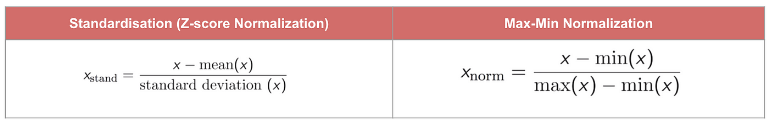

In [49]:
# So we will import standard scaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [50]:
x_sc = sc.fit_transform(x)
x_sc[0]

array([ 6.39947260e-01,  8.65040726e-01, -3.35182392e-02,  6.65502121e-01,
       -3.34507888e-16,  1.66291742e-01,  4.68491977e-01,  1.42599540e+00])

In [51]:
sc.inverse_transform([x_sc[0]]) # Standard data  into actual data

array([[  6.        , 148.        ,  72.        ,  35.        ,
        155.54822335,  33.6       ,   0.627     ,  50.        ]])

In [52]:
sc.transform([x.iloc[0,:8]]) # actual data to standard data

C:\Users\Victus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 6.39947260e-01,  8.65040726e-01, -3.35182392e-02,
         6.65502121e-01, -3.34507888e-16,  1.66291742e-01,
         4.68491977e-01,  1.42599540e+00]])

In [53]:
# Now divide the data into training and testing data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sc,y, test_size = 0.2, random_state=185,
                                                    stratify = y)


In [54]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614,) (154,)


# Import Model

In [55]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)

In [56]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [57]:
# Training Score of model
knn.score(x_train, y_train) # Low bias

0.8713355048859935

In [58]:
# Model Evaluation
# import some classes 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [59]:
y_pred  = knn.predict(x_test)
y_pred

array([0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1.,
       0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0.,
       1.])

In [60]:
accuracy_score(y_test, y_pred) # high Variance

0.7077922077922078

In [61]:
confusion_matrix(y_test, y_pred)

array([[74, 26],
       [19, 35]])

<Axes: >

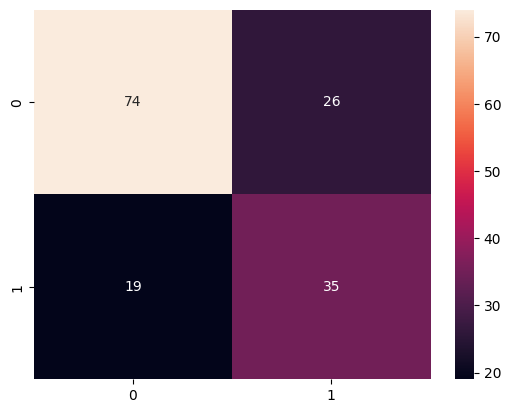

In [62]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True)

# Improve KNN model by changing values of K
# Find best K value

In [ ]:
er = []
test_acc = []
model_acc = []

for i in range(3,72,2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    er.append(np.mean(y_test != y_pred))
    test_acc.append(accuracy_score(y_test, y_pred))
    model_acc.append(knn.score(x_train, y_train))

In [ ]:
# to check the lowest error rate
plt.figure(figsize = (10,8))
plt.plot(range(3,72,2), er, marker = 'o')
plt.title('Error V/s K_value')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.xticks(range(3,62,2))
plt.yticks(er)
plt.show()


In [ ]:
# to check the highest Accuracy
plt.figure(figsize = (10,8))
plt.plot(range(3,72,2), test_acc, marker = 'o')
plt.title('Accuracy V/s K_value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(range(3,62,2))
plt.yticks(test_acc)
plt.grid()
plt.show()

In [ ]:
# to check the highest Accuracy
plt.figure(figsize = (10,8))
plt.plot(range(3,72,2), model_acc, marker = 'o')
plt.title('Model Accuracy V/s K_value')
plt.xlabel('K Value')
plt.ylabel('Model Accuracy')
plt.xticks(range(3,62,2))
plt.yticks(model_acc)
plt.grid()
plt.show()

In [ ]:
knn15 = KNeighborsClassifier(n_neighbors = 15)
knn15.fit(x_train, y_train)

In [ ]:
# Model training Score
knn15.score(x_train, y_train) # Bias

In [ ]:
y_pred_15 = knn15.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_15) # variance

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_15), annot = True)

In [ ]:
print(classification_report(y_test, y_pred_15))